# **Part 03:**

# **Time-Dependent Finite Element Solution of the Diffusion Equation Using the Implicit Euler Method**

## **Objectives**

Part 3 is mainly devoted to the finite element matrices assembled in Part 2 and the implicit Euler method to solve the time-dependent diffusion equation.

Specific objectives are:

1. The time derivative is discretized by the implicit Euler scheme;
2. verify that a uniform concentration is steady under zero-flux boundary conditions;
3. simulate the spread of a Gaussian concentration distribution;
4. compute the maximal and minimal concentration in each time level;
5. Check conservation of total concentration;
6. compute the discrete concentration energy;
7. contour plots for visualization of concentration evolution; and
8. Plot maximum concentration, total concentration, mass-conservation error and discrete energy versus time.

---

## **Algorithm:**
### Step 1: Start with the Semi-Discrete FEM System

$$
M\frac{d\mathbf{c}}{dt}
+
K\mathbf{c}
=
0.
$$

---

### Step 2: Define the Time Grid

$$
t_n=t_0+n\Delta t,
\qquad
n=0,1,\ldots,N_t.
$$

The number of time steps is

$$
N_t
=
\frac{t_f-t_0}{\Delta t}.
$$

For the present simulation,

$$
t_0=0,
\qquad
t_f=0.1,
\qquad
\Delta t=0.001,
$$

and therefore,

$$
N_t
=
\frac{0.1-0}{0.001}
=
100.
$$

---

### Step 3: Apply the Implicit Euler Approximation

Approximate the time derivative by

$$
\frac{d\mathbf{c}}{dt}
\approx
\frac{\mathbf{c}^{n+1}-\mathbf{c}^{n}}
{\Delta t}.
$$

Substitution into the FEM system gives

$$
M
\frac{\mathbf{c}^{n+1}-\mathbf{c}^{n}}
{\Delta t}
+
K\mathbf{c}^{n+1}
=
0.
$$

Multiplying by $\Delta t$ gives

$$
M\mathbf{c}^{n+1}
-
M\mathbf{c}^{n}
+
\Delta tK\mathbf{c}^{n+1}
=
0.
$$

Therefore,

$$
\left(M+\Delta tK\right)
\mathbf{c}^{n+1}
=
M\mathbf{c}^{n}.
$$

Define the system matrix as

$$
A=M+\Delta tK.
$$

---

### Step 4: Uniform-Concentration Test

Set the uniform initial concentration as

$$
\mathbf{c}^{0}
=
\mathbf{1}.
$$

At every time step, solve

$$
A\mathbf{c}^{n+1}
=
M\mathbf{c}^{n}.
$$

Calculate the uniform-solution error using

$$
E_{\mathrm{uniform}}
=
\max_i
\left|
c_i^{N_t}-c_i^0
\right|.
$$

For a correct zero-flux diffusion solver,

$$
E_{\mathrm{uniform}}
\approx0.
$$

---

### Step 5: Define the Gaussian Initial Concentration

The Gaussian initial condition is

$$
c(x,y,0)
=
\exp
\left[
-\frac{
(x-x_c)^2+(y-y_c)^2
}{
2\sigma^2
}
\right].
$$

For the present simulation,

$$
x_c=0.5,
\qquad
y_c=0.5,
\qquad
\sigma=0.15.
$$

Therefore,

$$
c(x,y,0)
=
\exp
\left[
-\frac{
(x-0.5)^2+(y-0.5)^2
}{
2(0.15)^2
}
\right].
$$

---

### Step 6: Perform Time Stepping

For every time level $n=0,1,\ldots,N_t-1$, calculate the right-hand side:

$$
\mathbf{b}^{n}
=
M\mathbf{c}^{n}.
$$

Then solve

$$
A\mathbf{c}^{n+1}
=
\mathbf{b}^{n}.
$$

Equivalently,

$$
\mathbf{c}^{n+1}
=
\left(M+\Delta tK\right)^{-1}
M\mathbf{c}^{n}.
$$

In the Python code, the inverse is not calculated explicitly. Instead, the linear system is solved using `np.linalg.solve()`.

---

### Step 7: Calculate the Maximum and Minimum Concentrations

At every time level, calculate

$$
c_{\max}^{n}
=
\max_i c_i^{n}
$$

and

$$
c_{\min}^{n}
=
\min_i c_i^{n}.
$$

For diffusion, the maximum concentration should decrease as the concentration peak spreads through the domain.

---

### Step 8: Calculate the Total Concentration

The discrete total concentration is

$$
m^n
=
\mathbf{1}^{T}
M\mathbf{c}^{n}.
$$

Under zero-flux boundary conditions, the total concentration should remain constant:

$$
m^n
\approx
m^0.
$$

---

### Step 9: Calculate the Relative Mass-Conservation Error

The relative mass-conservation error is

$$
E_{\mathrm{mass}}^n
=
\frac{
\left|m^n-m^0\right|
}{
\left|m^0\right|
}.
$$

The maximum mass-conservation error is

$$
E_{\mathrm{mass}}^{\max}
=
\max_n
E_{\mathrm{mass}}^n.
$$

For a correctly assembled numerical method,

$$
E_{\mathrm{mass}}^{\max}
\approx0.
$$

---

### Step 10: Calculate the Discrete Energy

The discrete concentration energy is calculated as

$$
E^n
=
\left(\mathbf{c}^{n}\right)^T
M\mathbf{c}^{n}.
$$

For a diffusion process, the energy should not increase:

$$
E^{n+1}
\leq
E^n.
$$

This represents the smoothing and dissipative behaviour of diffusion.

---

### Step 11: Verify the Numerical Solution

The following conditions are checked:

$$
E_{\mathrm{uniform}}
<
10^{-10},
$$

$$
E_{\mathrm{mass}}^{\max}
<
10^{-10},
$$

$$
E^{n+1}
\leq
E^n+10^{-12},
$$

and

$$
c_{\max}^{N_t}
<
c_{\max}^{0}.
$$

The concentration values must also satisfy

$$
c_i^n\in\mathbb{R}
$$

and must not contain undefined or infinite values.

---

### Step 12: Store Selected Solutions

Store the concentration at

$$
t=0,
\qquad
t=0.01,
\qquad
t=0.05,
\qquad
t=0.10.
$$

These solutions are used to create contour plots showing the diffusion of the initial Gaussian concentration.

---

### Step 13: Visualize the Results

Plot:

$$
c_{\max}^{n}
\quad\text{against}\quad
t_n,
$$

$$
m^n
\quad\text{against}\quad
t_n,
$$

$$
E_{\mathrm{mass}}^n
\quad\text{against}\quad
t_n,
$$

and

$$
E^n
\quad\text{against}\quad
t_n.
$$

Mesh successfully reconstructed.
Number of nodes: 169
Number of elements: 288
Total mesh area: 1.0
Number of nodes: 169
Number of elements: 288
Diffusion coefficient: 1.0
Global mass and stiffness matrices assembled.
Mass matrix shape: (169, 169)
Stiffness matrix shape: (169, 169)
Initial time: 0.0
Final time: 0.1
Time-step size: 0.001
Number of time steps: 100
Implicit Euler matrix shape: (169, 169)
Uniform-solution error: 1.6653345369377348e-15

Uniform concentration test passed successfully.
Initial maximum concentration: 1.0
Initial minimum concentration: 1.4945338524781451e-05
Time-dependent diffusion simulation completed.
Initial total concentration: 0.14105748358337672
Final total concentration: 0.141057483583377
Maximum relative mass error: 2.1644461819103247e-15
Initial maximum concentration: 1.0
Final maximum concentration: 0.14805655296630751
Initial discrete energy: 0.06725093174670156
Final discrete energy: 0.019908843660451748
Minimum concentration during simulation: 9.60

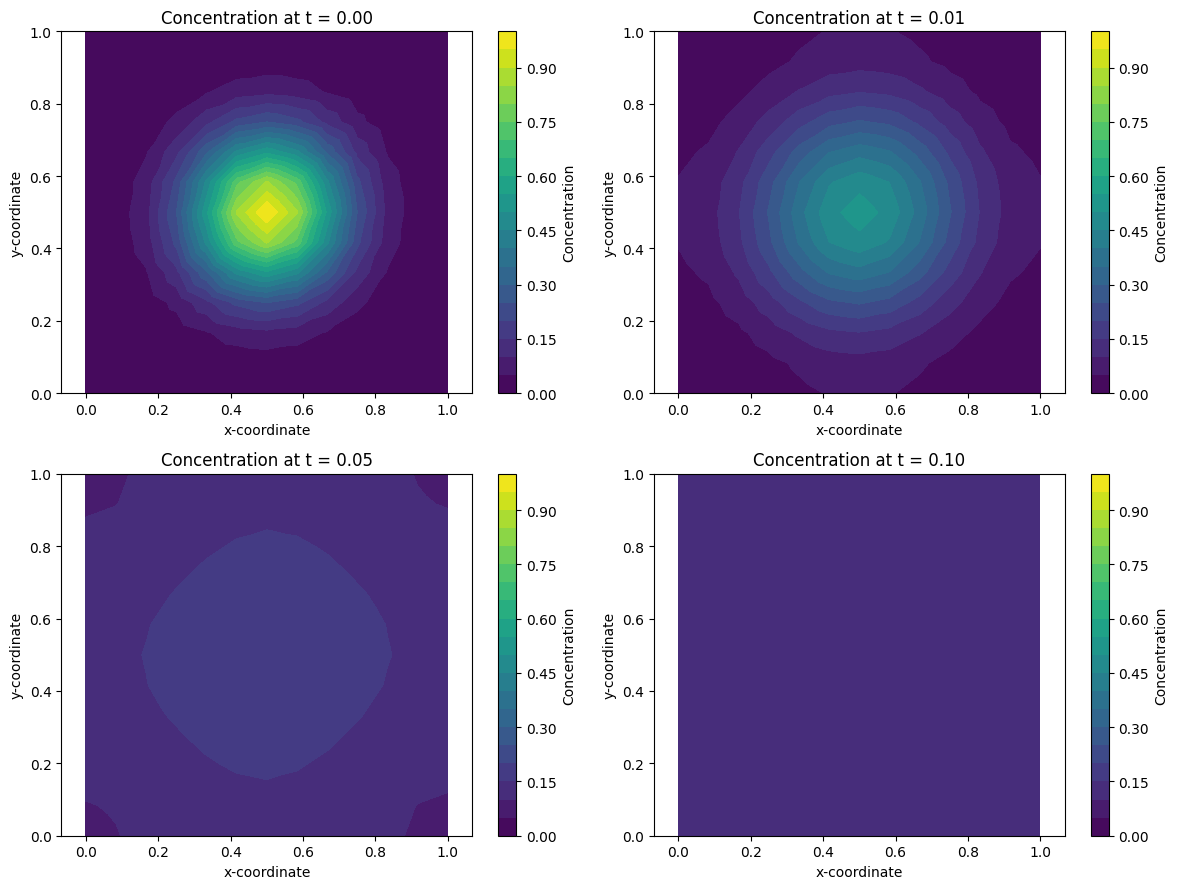

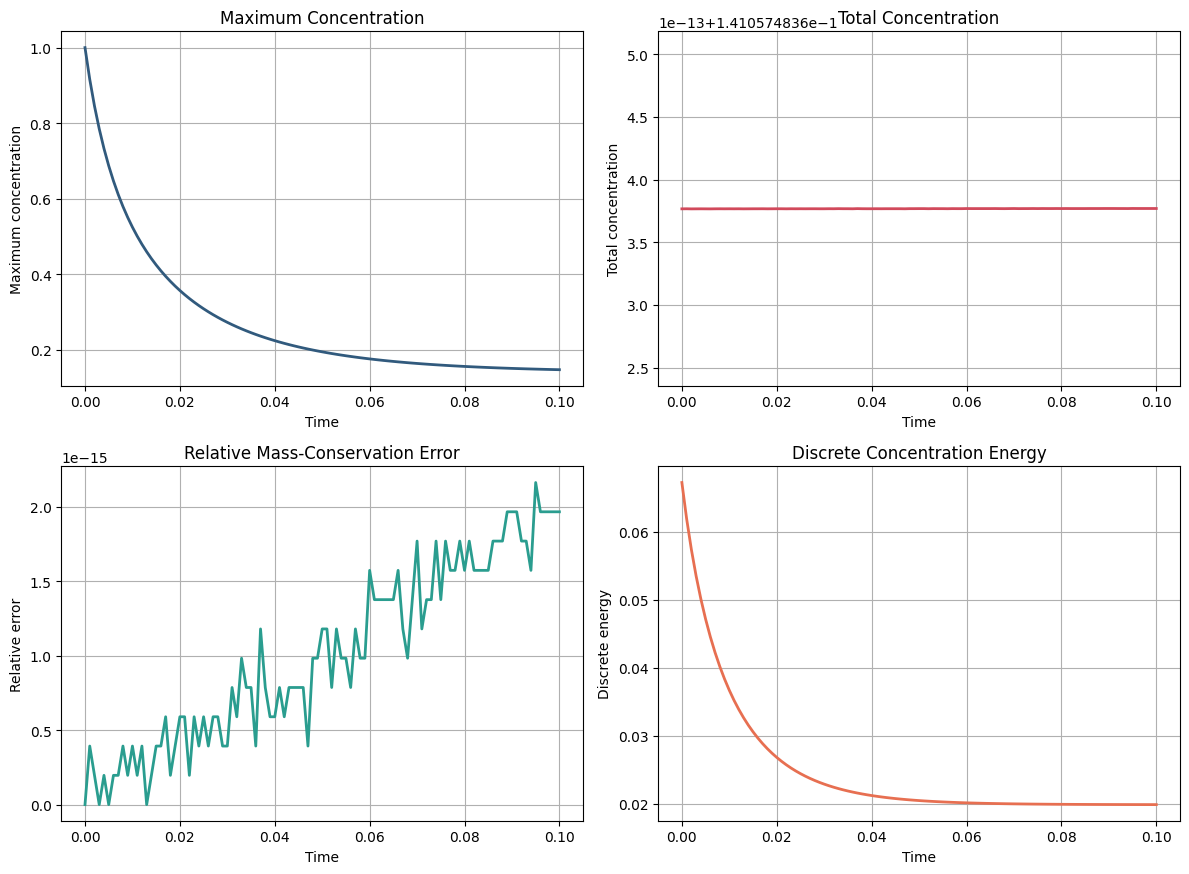

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
Lx = 1.0
Ly = 1.0
Nx = 12
Ny = 12
x = np.linspace(0.0, Lx, Nx + 1)
y = np.linspace(0.0, Ly, Ny + 1)
X, Y = np.meshgrid(x, y, indexing="xy")
nodes = np.column_stack((X.ravel(),Y.ravel()))
elements = []
for j in range(Ny):
    for i in range(Nx):
        n1 = j * (Nx + 1) + i
        n2 = n1 + 1
        n3 = n1 + (Nx + 1)
        n4 = n3 + 1
        elements.append([n1, n2, n4])
        elements.append([n1, n4, n3])
elements = np.asarray(elements, dtype=int)
# Calculate the signed areas
def calculate_signed_areas(node_coordinates,connectivity):
    p1 = node_coordinates[connectivity[:, 0]]
    p2 = node_coordinates[connectivity[:, 1]]
    p3 = node_coordinates[connectivity[:, 2]]
    areas = 0.5 * ((p2[:, 0] - p1[:, 0])* (p3[:, 1] - p1[:, 1])-(p3[:, 0] - p1[:, 0])* (p2[:, 1] - p1[:, 1]))
    return areas
number_of_nodes = len(nodes)
number_of_elements = len(elements)
D = 1.0
element_areas = calculate_signed_areas(nodes,elements)
print("Mesh successfully reconstructed.")
print("Number of nodes:", len(nodes))
print("Number of elements:", len(elements))
print("Total mesh area:", element_areas.sum())
print("Number of nodes:", number_of_nodes)
print("Number of elements:", number_of_elements)
print("Diffusion coefficient:", D)
global_mass = np.zeros((number_of_nodes, number_of_nodes))
global_stiffness = np.zeros((number_of_nodes, number_of_nodes))
# Assemble the global mass and stiffness matrices
for element_index in range(number_of_elements):
    element = elements[element_index]
    coordinates = nodes[element]
    x1, y1 = coordinates[0]
    x2, y2 = coordinates[1]
    x3, y3 = coordinates[2]
    area = element_areas[element_index]
    if area <= 0.0:
        raise ValueError("A reversed or degenerate element was found.")
    b_coefficients = np.array([y2 - y3, y3 - y1, y1 - y2])
    c_coefficients = np.array([x3 - x2, x1 - x3, x2 - x1])
    basis_gradients = np.column_stack((b_coefficients,c_coefficients)) / (2.0 * area)
    local_mass = (area / 12.0) * np.array([
        [2.0, 1.0, 1.0],
        [1.0, 2.0, 1.0],
        [1.0, 1.0, 2.0]])
    local_stiffness = (D * area* ( basis_gradients @ basis_gradients.T))
    # Add the local matrices to the global matrices
    for local_i in range(3):
        global_i = element[local_i]
        for local_j in range(3):
            global_j = element[local_j]
            global_mass[global_i,global_j] += local_mass[local_i,local_j]
            global_stiffness[global_i,global_j] += local_stiffness[local_i,local_j ]
print("Global mass and stiffness matrices assembled.")
print("Mass matrix shape:", global_mass.shape)
print("Stiffness matrix shape:", global_stiffness.shape)
# Check that the matrices are not zero
assert np.count_nonzero(global_mass) > 0, "The global mass matrix was not assembled."
assert np.count_nonzero(global_stiffness) > 0, "The global stiffness matrix was not assembled."
# Time dependent diffusion using implicit euler
initial_time = 0.0
final_time = 0.1
time_step = 0.001
number_of_time_steps = int(round((final_time - initial_time)/ time_step))
time_values = np.linspace(initial_time,final_time,number_of_time_steps + 1)
print("Initial time:", initial_time)
print("Final time:", final_time)
print("Time-step size:", time_step)
print("Number of time steps:", number_of_time_steps)
# Implicit Euler system matrix
system_matrix = (global_mass+time_step * global_stiffness)
print("Implicit Euler matrix shape:",system_matrix.shape)
assert system_matrix.shape == (number_of_nodes,number_of_nodes), "The implicit Euler matrix has incorrect dimensions."
# Uniform initial concentration
uniform_initial_concentration = np.ones(number_of_nodes)
uniform_solution = (uniform_initial_concentration.copy())
# Perform implicit Euler time stepping
for time_step_index in range(1,number_of_time_steps + 1):
    right_hand_side = ( global_mass @ uniform_solution)
    uniform_solution = np.linalg.solve(system_matrix,right_hand_side)
# Calculate the maximum uniform-solution error
uniform_solution_error = np.max(np.abs(uniform_solution - uniform_initial_concentration))
print("Uniform-solution error:",uniform_solution_error)
assert uniform_solution_error < 1.0e-10, "The solver does not preserve a uniform concentration."
print("\nUniform concentration test passed successfully.")
# Width of the initial Gaussian concentration
sigma = 0.15
# Centre of the concentration peak
centre_x = 0.5
centre_y = 0.5
# Gaussian initial concentration
initial_concentration = np.exp(-((nodes[:, 0] - centre_x) ** 2+(nodes[:, 1] - centre_y) ** 2)/(2.0 * sigma ** 2))
# Current numerical solution
concentration = initial_concentration.copy()
print("Initial maximum concentration:",np.max(initial_concentration))
print("Initial minimum concentration:",np.min(initial_concentration))
# Arrays for storing numerical results
maximum_concentration = np.zeros(number_of_time_steps + 1)
minimum_concentration = np.zeros(number_of_time_steps + 1)
total_concentration = np.zeros(number_of_time_steps + 1)
discrete_energy = np.zeros(number_of_time_steps + 1)
constant_vector = np.ones(number_of_nodes)
# Store initial values
maximum_concentration[0] = np.max(concentration)
minimum_concentration[0] = np.min(concentration)
total_concentration[0] = (constant_vector@ global_mass@ concentration)
discrete_energy[0] = (concentration@ global_mass@ concentration)
# Time levels selected for visualization
selected_times = [ 0.0, 0.01, 0.05, 0.10]
selected_steps = [int(round(time / time_step))for time in selected_times]
# Store the initial concentration
concentration_snapshots = {0: concentration.copy()}
for time_step_index in range(1,number_of_time_steps + 1):
    right_hand_side = (global_mass@ concentration)
    concentration = np.linalg.solve(system_matrix,right_hand_side)
    maximum_concentration[time_step_index] = (np.max(concentration))
    minimum_concentration[time_step_index] = (np.min(concentration))
    total_concentration[time_step_index] = (constant_vector@ global_mass @ concentration)
    discrete_energy[time_step_index] = (concentration@ global_mass @ concentration)
    if time_step_index in selected_steps:
        concentration_snapshots[time_step_index] = concentration.copy()
print("Time-dependent diffusion simulation completed.")
relative_mass_error = np.abs(total_concentration - total_concentration[0]) / np.abs(total_concentration[0])
maximum_mass_error = np.max(relative_mass_error)
all_values_are_finite = np.all(np.isfinite(concentration))
# Check whether the discrete energy decreases
energy_differences = np.diff(discrete_energy)
energy_is_nonincreasing = np.all(energy_differences <= 1.0e-12)
print( "Initial total concentration:", total_concentration[0])
print("Final total concentration:",total_concentration[-1])
print("Maximum relative mass error:",maximum_mass_error)
print("Initial maximum concentration:",maximum_concentration[0])
print( "Final maximum concentration:", maximum_concentration[-1])
print("Initial discrete energy:",discrete_energy[0])
print("Final discrete energy:",discrete_energy[-1])
print("Minimum concentration during simulation:",np.min(minimum_concentration))
assert all_values_are_finite, "The solution contains NaN or infinite values."
assert maximum_mass_error < 1.0e-10, "The total concentration is not conserved."
assert energy_is_nonincreasing, "The discrete energy does not decrease."
assert maximum_concentration[-1] < maximum_concentration[0], "The concentration peak did not decrease."
print("\nAll time-dependent diffusion checks passed successfully.")
# Use the same colour levels in all contour plots
contour_levels = np.linspace(np.min(initial_concentration),np.max(initial_concentration),21)
plt.figure(figsize=(12, 9))
for plot_number, step in enumerate(selected_steps,start=1):
    plt.subplot(2, 2, plot_number)
    contour_plot = plt.tricontourf(nodes[:, 0],nodes[:, 1],elements,concentration_snapshots[step],levels=contour_levels,cmap="viridis")
    plt.colorbar(contour_plot,label="Concentration")
    plt.title(f"Concentration at "f"t = {time_values[step]:.2f}")
    plt.xlabel("x-coordinate")
    plt.ylabel("y-coordinate")
    plt.axis("equal")
plt.tight_layout()
plt.savefig("concentration_evolution.png",dpi=300,bbox_inches="tight")
plt.show()

plt.figure(figsize=(12, 9))
# Maximum concentration
plt.subplot(2, 2, 1)
plt.plot(time_values, maximum_concentration, color="#315A7D", linewidth=2)
plt.title("Maximum Concentration")
plt.xlabel("Time")
plt.ylabel("Maximum concentration")
plt.grid(True)
# Total concentration
plt.subplot(2, 2, 2)
plt.plot(time_values,total_concentration,color="#D1495B",linewidth=2)
plt.title("Total Concentration")
plt.xlabel("Time")
plt.ylabel("Total concentration")
plt.grid(True)
# Relative mass error
plt.subplot(2, 2, 3)
plt.plot( time_values, relative_mass_error, color="#2A9D8F", linewidth=2)
plt.title("Relative Mass-Conservation Error")
plt.xlabel("Time")
plt.ylabel("Relative error")
plt.grid(True)
# Discrete energy
plt.subplot(2, 2, 4)
plt.plot(time_values, discrete_energy, color="#E76F51", linewidth=2)
plt.title("Discrete Concentration Energy")
plt.xlabel("Time")
plt.ylabel("Discrete energy")
plt.grid(True)
plt.tight_layout()
plt.savefig("diffusion_verification_graphs.png",dpi=300,bbox_inches="tight")
plt.show()

## Results and Interpretation

The time-dependent diffusion equation was solved from $t=0$ to $t=0.1$ using the finite element method and implicit Euler time integration with

$$
\Delta t=0.001.
$$

A total of 100 time steps were performed.

### **Verification of Uniform-Concentration**

The uniform initial condition was preserved with a maximum error of

$$
1.6653\times10^{-15}.
$$

This value is effectively zero and is caused by floating-point rounding. It confirms that the numerical method correctly preserves a constant concentration under zero-flux boundary conditions.

### **Evolution of the Gaussian Concentration**

The initial Gaussian concentration had a maximum value of

$$
c_{\max}(0)=1.
$$

At the final time, the maximum concentration decreased to

$$
c_{\max}(0.1)\approx0.14806.
$$

The contour plots show that the initially concentrated peak at the centre of the domain gradually became lower and wider. This is the expected behaviour of diffusion: concentration moves from regions of high concentration toward surrounding regions of lower concentration.

The concentration remained positive throughout the simulation. The minimum recorded value was approximately

$$
9.61\times10^{-6}.
$$

Therefore, the numerical solution did not produce significant negative concentrations or invalid values.

### **Mass Concentration**

The initial and final total concentrations were

$$
m(0)=0.14105748358337672
$$

and

$$
m(0.1)=0.141057483583377.
$$

These values are equal to numerical precision. The maximum relative mass-conservation error was

$$
2.16\times10^{-15},
$$

which is effectively zero. This confirms that the finite element solution conserves the total concentration under zero-flux boundary conditions.

### **Discrete Energy**

The discrete concentration energy decreased from

$$
E(0)=0.06725093
$$

to

$$
E(0.1)=0.01990884.
$$

This decrease represents the smoothing effect of diffusion. As the central concentration peak spreads through the domain, sharp spatial concentration differences are reduced.

### **Graphs Interpretations**

The graph of maximum-concentration decreases monotonically as the central peak extends into the surrounding domain.

The graph of the total concentration is approximately constant. This confirms the conservation of concentration.

The relative mass-error graph stays close to zero, which shows high numerical conservation accuracy.

The discrete energy graph decreases with time which confirms the dissipative and smoothing behavior of the diffusion process .

In general, all the numerical verification checks were successful. The results confirm the expected behavior of a time dependent diffusion process for the finite element spatial discretization and the implicit Euler time integration.
